### WorldModel 좌표계 연산량 비교 벤치마크
- Odom 좌표계와 Egocentric 좌표계의 회전/이동 시 연산 부하 비교

In [16]:
import numpy as np
import os
import time
import cv2
import matplotlib.pyplot as plt
import rerun as rr
import rerun.blueprint as rrb

rr.disconnect()
rr.init("Kitti_Benchmark", spawn=False)
rr.log("world", rr.ViewCoordinates.RDF, static=True)
rr.log("robot", rr.ViewCoordinates.RDF, static=True)

In [17]:


class KittiLoader:
    def __init__(self, dataset_path, sequence="00"):
        self.sequence_path = os.path.join(dataset_path, "sequences", sequence)
        self.pose_path = os.path.join(dataset_path, "poses", f"{sequence}.txt")
        self.calib_path = os.path.join(self.sequence_path, "calib.txt")
        
        self.lidar_files = sorted(os.listdir(os.path.join(self.sequence_path, "velodyne")))
        self.img_files = sorted(os.listdir(os.path.join(self.sequence_path, "image_2")))
        self.poses = self.load_poses(self.pose_path)
        self.calib = self.load_calib(self.calib_path)

    def load_poses(self, path):
        poses = []
        with open(path, 'r') as f:
            for line in f.readlines():
                T = np.fromstring(line, sep=' ').reshape(3, 4)
                T = np.vstack((T, [0, 0, 0, 1]))
                poses.append(T)
        return poses
    
    def load_calib(self, path):
        with open(path, 'r') as f:
            lines = f.readlines()
        P2 = np.fromstring(lines[2].strip().split(': ')[1], sep=' ').reshape(3, 4)
        Tr = np.fromstring(lines[4].strip().split(': ')[1], sep=' ').reshape(3, 4)
        Tr = np.vstack((Tr, [0, 0, 0, 1]))
        return {"P2": P2, "Tr": Tr}

    def get_frame(self, index):
        #lidar point 로드
        lidar_path = os.path.join(self.sequence_path, "velodyne", self.lidar_files[index])
        scan = np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 4)
        points = scan[:, :3]
        
        #이미지 로드
        img_path = os.path.join(self.sequence_path, "image_2", self.img_files[index])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        # 3D 점을 2D 이미지로 투영하여 색상 추출
        points_homo = np.hstack((points, np.ones((points.shape[0], 1))))
        pts_cam = (self.calib["Tr"] @ points_homo.T).T #카메라 3D 좌표
        pts_img = (self.calib["P2"] @ pts_cam.T).T #이미지 2D 좌표
        
        # 정규화 (z로 나눔)
        u = (pts_img[:, 0] / pts_img[:, 2]).astype(int)
        v = (pts_img[:, 1] / pts_img[:, 2]).astype(int)

        # 이미지 영역 안에 들어오는 점들만 필터링
        mask = (u >= 0) & (u < w) & (v >= 0) & (v < h) & (pts_cam[:, 2] > 0)
        
        colors = np.full((points.shape[0], 3), 128, dtype=np.uint8)
        colors[mask] = img[v[mask], u[mask]]
        
        return points, self.poses[index], colors
    
class SyntheticLoader:
    def __init__(self, num_frames=100, points_per_frame=5000):
        self.num_frames = num_frames
        self.points_per_frame = points_per_frame
        self.calib = {"Tr": np.eye(4)}  # LiDAR = 카메라 좌표로 가정
        
        self.poses = []
        current_pose = np.eye(4)
        # 매 프레임마다 0.5m 전진, 2도 z축 회전
        for i in range(num_frames):
            self.poses.append(current_pose.copy())
            theta = np.radians(2.0)
            T_move = np.array([
                [np.cos(theta), -np.sin(theta), 0, 0.5],
                [np.sin(theta),  np.cos(theta), 0, 0.0],
                [0,              0,             1, 0.0],
                [0,              0,             0, 1.0]
            ])
            current_pose = current_pose @ T_move

    def get_frame(self, index):
        points = np.random.rand(self.points_per_frame, 3) * 10.0
        points[:, 2] = np.random.rand(self.points_per_frame) * 2.0 #높이는 2m 내외
        
        # 호환성을 위한 가짜 색상 데이터
        colors = np.full((self.points_per_frame, 3), [200, 200, 200], dtype=np.uint8)
        
        return points, self.poses[index], colors

In [18]:
def benchmark_accumulated_maps(loader, num_frames):
    odom_map = np.empty((0, 3))
    ego_map = np.empty((0, 3))
    map_colors = np.empty((0, 3), dtype=np.uint8)
    
    odom_times = []
    ego_times = []
    prev_pose = np.eye(4)
    
    for i in range(num_frames):
        new_points, current_pose, new_colors = loader.get_frame(i)
        new_points_homo = np.hstack((new_points, np.ones((new_points.shape[0], 1))))

        # Tr 적용: LiDAR → 카메라 좌표
        pts_cam = (loader.calib["Tr"] @ new_points_homo.T).T
        pts_cam_xyz = pts_cam[:, :3]
        
        # Odom: 새 포인트만 변환
        start_time = time.perf_counter()
        transformed_new_points = (current_pose @ pts_cam.T).T[:, :3]
        odom_times.append(time.perf_counter() - start_time)
        
        odom_map = np.vstack((odom_map, transformed_new_points))
        
        # Egocentric: 누적된 전체 포인트 재변환
        start_time = time.perf_counter()
        if i > 0 and ego_map.shape[0] > 0:
            inv_current_pose = np.linalg.inv(current_pose)
            relative_transform = inv_current_pose @ prev_pose
            
            ego_map_homo = np.hstack((ego_map, np.ones((ego_map.shape[0], 1))))
            ego_map = (relative_transform @ ego_map_homo.T).T[:, :3]
        ego_times.append(time.perf_counter() - start_time)
            
        ego_map = np.vstack((ego_map, pts_cam_xyz))
        map_colors = np.vstack((map_colors, new_colors))
        
        prev_pose = current_pose.copy()
        
        if i % 10 == 0:
            MAX_VIZ = 50_000
            idx = np.random.choice(len(odom_map), min(MAX_VIZ, len(odom_map)), replace=False)
            rr.set_time("frame", sequence=i)
            rr.log("world/odom_map", rr.Points3D(odom_map[idx], colors=map_colors[idx]))
            rr.log("robot/ego_map", rr.Points3D(ego_map[idx], colors=map_colors[idx]))
        
    return odom_times, ego_times

In [19]:
# 실행
DATA_PATH = "/project/jeongin/kitti_data/dataset" 
num_test_frames = 100

if os.path.exists(DATA_PATH) and os.path.exists(os.path.join(DATA_PATH, "sequences")):
    print("KITTI Dataset found. Initializing KittiLoader.")
    loader = KittiLoader(dataset_path=DATA_PATH, sequence="00")
else:
    print("KITTI Dataset not found. Falling back to SyntheticLoader.")
    loader = SyntheticLoader(num_frames=num_test_frames, points_per_frame=5000)

print("Benchmarking started...")
odom_times, ego_times = benchmark_accumulated_maps(loader, num_frames=num_test_frames)
print("Benchmarking completed.")


blueprint = rrb.Blueprint(
    rrb.Horizontal(
        rrb.Spatial3DView(name="World (Odom)", origin="world"),
        rrb.Spatial3DView(name="Robot (Ego)", origin="robot"),
    )
)
rr.notebook_show(blueprint=blueprint, width=1400, height=800)

KITTI Dataset found. Initializing KittiLoader.
Benchmarking started...
Benchmarking completed.


HTML(value='<div id="cc2bdd5d-c3c0-409f-85b1-8fd9d6971531"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

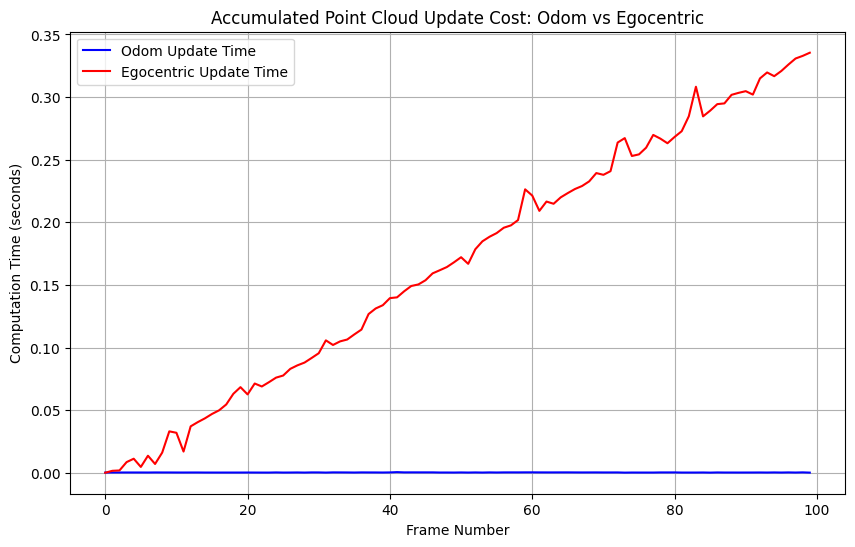

In [20]:
# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(odom_times, label='Odom Update Time', color='blue')
plt.plot(ego_times, label='Egocentric Update Time', color='red')
plt.legend()
plt.title("Accumulated Point Cloud Update Cost: Odom vs Egocentric")
plt.xlabel("Frame Number")
plt.ylabel("Computation Time (seconds)")
plt.grid(True)
plt.show()